# 05 - Décision par règles

## Objectif

Construire une première classification sans machine learning : on extrait quelques mesures puis on applique des seuils pour prédire OK ou Defective.

In [6]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

import pandas as pd

from src.evaluation import classification_report_dataframe, compute_metrics, plot_confusion_matrix, save_metrics
from src.features import build_features_dataframe
from src.rules import calibrate_rules_from_ok_samples, explain_rule_decision, predict_dataframe_by_rules
from src.utils import FEATURES_DIR, METRICS_DIR, build_image_index

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Chargement des caractristiques

Pour l'?valuation officielle, ce notebook utilise le fichier complet `data/features/casting_features.csv` s'il existe. Cela ?vite d'?valuer les r?gles sur un petit sous-?chantillon de 200 images.

Si le fichier n'existe pas encore, le notebook extrait les caract?ristiques depuis toutes les images du dataset. Pour une d?monstration rapide seulement, on peut renseigner `SAMPLE_PER_GROUP`, mais il doit rester ? `None` pour les m?triques finales.

In [7]:
USE_SAVED_FEATURES = True
SAMPLE_PER_GROUP = None  # garder None pour l'?valuation compl?te

index_df = build_image_index()
features_path = FEATURES_DIR / "casting_features.csv"

if index_df.empty and not features_path.exists():
    raise FileNotFoundError("Aucune image trouv?e dans data/raw/casting_data/ et aucun fichier de caract?ristiques disponible.")

if USE_SAVED_FEATURES and features_path.exists():
    features_df = pd.read_csv(features_path)
    feature_source = str(features_path)
else:
    if SAMPLE_PER_GROUP is None:
        index_used = index_df
    else:
        index_used = (
            index_df.groupby(["split", "label_name"], group_keys=False)
            .apply(lambda group: group.sample(n=min(SAMPLE_PER_GROUP, len(group)), random_state=42))
            .reset_index(drop=True)
        )
    features_df = build_features_dataframe(index_used)
    feature_source = "extraction directe depuis data/raw/casting_data"

print("Source des caract?ristiques :", feature_source)
print(f"Nombre total de lignes : {len(features_df)}")
display(features_df.groupby(["split", "label_name"]).size().reset_index(name="count"))
display(features_df[["filename", "split", "label_name", "defect_count", "defect_area_ratio", "largest_defect_area_ratio"]].head())

Source des caract?ristiques : C:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\industrial-defect-detection2\data\features\casting_features.csv
Nombre total de lignes : 7348


,split,label_name,count
0,test,Defective,453
1,test,OK,262
2,train,Defective,3758
3,train,OK,2875


,filename,split,label_name,defect_count,defect_area_ratio,largest_defect_area_ratio
0,cast_ok_0_1.jpeg,train,OK,8.0,0.166644,0.127411
1,cast_ok_0_1001.jpeg,train,OK,9.0,0.291122,0.135011
2,cast_ok_0_1002.jpeg,train,OK,10.0,0.286756,0.118989
3,cast_ok_0_1003.jpeg,train,OK,5.0,0.171722,0.127567
4,cast_ok_0_1005.jpeg,train,OK,7.0,0.352256,0.215433


## 2. Calibration des seuils

Les seuils sont estimés à partir des images OK du train. L'idée est simple : une image devient suspecte si elle dépasse fortement ce qui est observé sur les pièces normales.

In [8]:
config = calibrate_rules_from_ok_samples(features_df)

print("Configuration des r?gles utilis?e :")
display(pd.DataFrame([config.__dict__]))

Configuration des r?gles utilis?e :


,max_defect_area_ratio,max_largest_defect_area_ratio,max_defect_count,max_intensity_mean,max_intensity_p90,min_dark_pixel_ratio,min_hist_01_ratio,min_defect_count,min_texture_dissimilarity,min_rule_score
0,0.406829,0.250385,13.2,153.77269,214.0,0.118061,0.047883,9.0,0.419325,3.0


## 3. Prédictions par règles

On applique les seuils à toutes les images du tableau.

In [9]:
features_df["rule_pred"] = predict_dataframe_by_rules(features_df, config)
features_df["rule_pred_name"] = features_df["rule_pred"].map({0: "OK", 1: "Defective"})

print("Exemple d'explication sur une image :")
print(explain_rule_decision(features_df.iloc[0], config))

display(features_df[["filename", "split", "label_name", "rule_pred_name", "defect_area_ratio", "defect_count"]].head(10))

Exemple d'explication sur une image :
Prediction: OK (score=0.0/3.0, mesures sous les seuils)


,filename,split,label_name,rule_pred_name,defect_area_ratio,defect_count
0,cast_ok_0_1.jpeg,train,OK,OK,0.166644,8.0
1,cast_ok_0_1001.jpeg,train,OK,OK,0.291122,9.0
2,cast_ok_0_1002.jpeg,train,OK,Defective,0.286756,10.0
3,cast_ok_0_1003.jpeg,train,OK,OK,0.171722,5.0
4,cast_ok_0_1005.jpeg,train,OK,OK,0.352256,7.0
5,cast_ok_0_1009.jpeg,train,OK,OK,0.336211,4.0
6,cast_ok_0_101.jpeg,train,OK,OK,0.168233,5.0
7,cast_ok_0_1013.jpeg,train,OK,OK,0.237167,4.0
8,cast_ok_0_1016.jpeg,train,OK,OK,0.337300,4.0
9,cast_ok_0_1019.jpeg,train,OK,OK,0.246411,7.0


## 4. Évaluation sur le test

On calcule les métriques principales si le split test est présent dans les données traitées.

Source ?valu?e : C:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\industrial-defect-detection2\data\features\casting_features.csv
Jeu de test complet : 715 images (262 OK, 453 Defective)


,accuracy,precision,recall,f1_score
0,0.827972,0.796763,0.977925,0.878097


,precision,recall,f1-score,support
OK,0.937107,0.568702,0.707838,262.000000
Defective,0.796763,0.977925,0.878097,453.000000
accuracy,0.827972,0.827972,0.827972,0.827972
macro avg,0.866935,0.773314,0.792968,715.000000
weighted avg,0.848189,0.827972,0.815709,715.000000


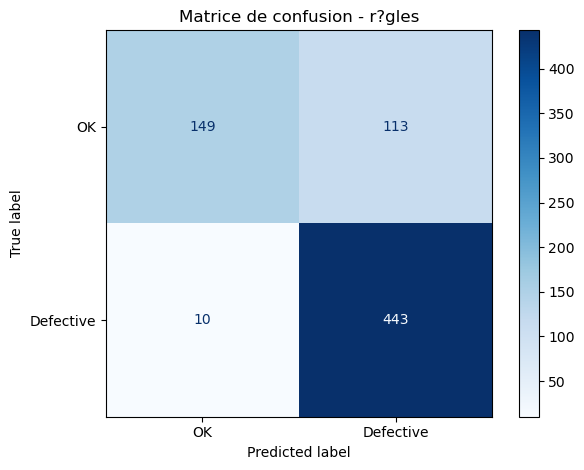

In [10]:
test_df = features_df[features_df["split"] == "test"].copy()

if test_df.empty:
    raise ValueError("Aucune image test dans les caract?ristiques. V?rifiez data/features/casting_features.csv ou la structure du dataset.")

metrics = compute_metrics(test_df["label"], test_df["rule_pred"])
metadata = {
    "source_features": feature_source,
    "test_rows": int(len(test_df)),
    "test_ok": int((test_df["label"] == 0).sum()),
    "test_defective": int((test_df["label"] == 1).sum()),
    "rule_config": config.__dict__,
}

print("Source ?valu?e :", feature_source)
print(f"Jeu de test complet : {metadata['test_rows']} images ({metadata['test_ok']} OK, {metadata['test_defective']} Defective)")
display(pd.DataFrame([metrics]))
display(classification_report_dataframe(test_df["label"], test_df["rule_pred"]))

save_metrics(metrics, METRICS_DIR / "rules_metrics.json")
save_metrics({"metrics": metrics, "metadata": metadata}, METRICS_DIR / "rules_metrics_detailed.json")
plot_confusion_matrix(test_df["label"], test_df["rule_pred"], "Matrice de confusion - r?gles")

## Conclusion

Cette approche est interprétable et rapide. Sa limite principale est qu'elle dépend fortement des seuils et de la qualité de la segmentation.